# Exploração dos dados — camada Gold do CineData

Antes de escrever o prompt do agente eu quis entender bem o `cinerocket.db`. A lógica é simples:
**se eu mesmo não sei as pegadinhas dos dados, o LLM também não vai saber** e vai devolver
respostas erradas com muita confiança.

Cada achado deste notebook virou uma regra na seção "Regras de negócio" do prompt
(`cinedata_agent/prompts.py`). O resumo está no final.

In [1]:
import sqlite3
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DB = Path("..") / "data" / "cinerocket.db"
URI = f"file:{DB.resolve().as_posix()}?mode=ro"  # só leitura
conn = sqlite3.connect(URI, uri=True)

def q(sql):
    return pd.read_sql_query(sql, conn)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Visão geral das tabelas

In [2]:
tabelas = q("SELECT name FROM sqlite_master WHERE type='table' AND name <> 'alembic_version' ORDER BY name")["name"]
pd.DataFrame({"tabela": tabelas, "linhas": [q(f"SELECT COUNT(*) AS n FROM {t}")["n"][0] for t in tabelas]})

,tabela,linhas
0,bridge_movie_company,116326
1,bridge_movie_genre,121521
2,bridge_movie_person,745450
3,dim_companies,45941
4,dim_genres,19
5,dim_movies,95645
6,dim_people,424656
7,dim_reviews,40267
8,fact_movies_performance,95645
9,movie_reviews,43666


Modelo dimensional clássico: uma fato (`fact_movies_performance`, 1 linha por filme), dimensões e
três *bridges* para as relações N:N (gênero, pessoa e produtora). As chaves `sk_*` são hashes de
64 caracteres — isso deixa os JOINs um pouco mais lentos que chave inteira.

## 2. Receita, orçamento e lucro

In [3]:
q("""
SELECT COUNT(*) AS filmes,
       SUM(receita_usd IS NOT NULL)   AS com_receita,
       SUM(orcamento_usd IS NOT NULL) AS com_orcamento,
       SUM(receita_usd IS NOT NULL AND orcamento_usd IS NOT NULL) AS com_os_dois,
       SUM(lucro_usd IS NULL) AS lucro_nulo
FROM fact_movies_performance
""")

,filmes,com_receita,com_orcamento,com_os_dois,lucro_nulo
0,95645,3373,7926,1630,0


Só **3,5%** dos filmes têm receita. E o mais importante: **o lucro nunca é nulo**, mesmo quando falta
receita. Como ele foi calculado então?

In [4]:
q("""
SELECT CASE WHEN receita_usd IS NULL AND orcamento_usd IS NULL THEN 'sem receita e sem orçamento'
            WHEN receita_usd IS NULL THEN 'sem receita'
            WHEN orcamento_usd IS NULL THEN 'sem orçamento'
            ELSE 'com os dois' END AS caso,
       COUNT(*) AS filmes,
       SUM(lucro_usd = -orcamento_usd) AS lucro_igual_menos_orcamento,
       SUM(lucro_usd = receita_usd)    AS lucro_igual_receita,
       SUM(lucro_usd = 0)              AS lucro_zero
FROM fact_movies_performance GROUP BY caso
""")

,caso,filmes,lucro_igual_menos_orcamento,lucro_igual_receita,lucro_zero
0,com os dois,1630,0.00,0.00,56
1,sem orçamento,1743,NaN,"1,743.00",0
2,sem receita,6296,"6,296.00",NaN,0
3,sem receita e sem orçamento,85976,NaN,NaN,85976


**Pegadinha 1:** o lucro foi calculado tratando nulo como zero. Filme sem receita aparece com
prejuízo igual ao orçamento inteiro, e filme sem orçamento aparece com lucro = receita. Somar
`lucro_usd` direto (ex.: "produtora com maior lucro total") mistura lucro real com prejuízo falso.

➡️ Regra: lucro só com receita **e** orçamento informados, a menos que o usuário peça outro critério.

### Câmbio usado na conversão para R$

In [5]:
cambio = q("""
SELECT receita_brl / receita_usd AS cambio_receita, orcamento_brl / orcamento_usd AS cambio_orcamento
FROM fact_movies_performance WHERE receita_usd > 0 AND orcamento_usd > 0
""")
cambio.describe().T[["mean", "min", "max"]]

,mean,min,max
cambio_receita,3.98,3.00,5.78
cambio_orcamento,3.73,3.00,5.76


O mínimo dos dois é exatamente 3,0... desconfiei de câmbio "redondo". Contando quantas conversões
usaram uma taxa inteira (3,0 / 4,0 / 5,0):

In [6]:
q("""
SELECT 'orçamento' AS coluna, COUNT(*) AS filmes,
       SUM(ABS(orcamento_brl / orcamento_usd - ROUND(orcamento_brl / orcamento_usd)) < 0.0005) AS cambio_inteiro
FROM fact_movies_performance WHERE orcamento_usd > 0
UNION ALL
SELECT 'receita', COUNT(*),
       SUM(ABS(receita_brl / receita_usd - ROUND(receita_brl / receita_usd)) < 0.0005)
FROM fact_movies_performance WHERE receita_usd > 0
""")

,coluna,filmes,cambio_inteiro
0,orçamento,7926,4700
1,receita,3373,599


In [7]:
q("""
SELECT COUNT(*) AS filmes_com_os_dois,
       SUM(ABS(receita_brl / receita_usd - orcamento_brl / orcamento_usd) > 0.001) AS cambios_diferentes,
       SUM(ABS(100.0 * (receita_usd - orcamento_usd) / receita_usd
             - 100.0 * (receita_brl - orcamento_brl) / receita_brl) > 5) AS margem_muda_mais_de_5pp
FROM fact_movies_performance WHERE receita_usd > 0 AND orcamento_usd > 0
""")

,filmes_com_os_dois,cambios_diferentes,margem_muda_mais_de_5pp
0,1630,1058,8


**Pegadinha 2:** 59% dos orçamentos foram convertidos para R$ com câmbio **truncado** (3,0, 4,0...),
enquanto a maioria das receitas usou o câmbio "quebrado" da época. Em 2/3 dos filmes com receita e
orçamento os dois valores foram convertidos com taxas diferentes. Na prática a margem em R$ muda
pouco (só 8 filmes mudam mais de 5 pontos percentuais), mas não faz sentido calcular uma razão
misturando duas taxas. ➡️ Regra: margens e percentuais em **US$** (moeda original).

### Margem de lucro média por gênero: média simples × ponderada

In [8]:
margens = q("""
SELECT g.nome_genero AS genero,
       AVG((f.receita_usd - f.orcamento_usd) * 100.0 / f.receita_usd) AS margem_media_simples,
       SUM(f.receita_usd - f.orcamento_usd) * 100.0 / SUM(f.receita_usd) AS margem_ponderada,
       COUNT(*) AS filmes
FROM fact_movies_performance f
JOIN bridge_movie_genre bg ON bg.sk_movie_id = f.sk_movie_id
JOIN dim_genres g ON g.sk_genre_id = bg.sk_genre_id
WHERE f.receita_usd IS NOT NULL AND f.orcamento_usd IS NOT NULL
GROUP BY g.nome_genero ORDER BY margem_ponderada DESC
""")
margens

,genero,margem_media_simples,margem_ponderada,filmes
0,Horror,"-1,426.56",75.92,168
1,Adventure,"-1,313.73",69.59,246
2,Animation,-845.31,69.45,97
3,Family,"-1,335.65",68.96,142
4,Science Fiction,"-3,380.72",68.67,134
5,War,-534.88,66.78,57
6,Music,-640.95,66.68,45
7,Action,"-1,233.02",66.67,379
8,Fantasy,"-1,616.99",65.39,134
9,Comedy,"-14,846.63",65.04,403


In [9]:
q("""
SELECT m.titulo, f.receita_usd, f.orcamento_usd,
       ROUND((f.receita_usd - f.orcamento_usd) * 100.0 / f.receita_usd, 1) AS margem_pct
FROM fact_movies_performance f JOIN dim_movies m ON m.sk_movie_id = f.sk_movie_id
WHERE f.receita_usd IS NOT NULL AND f.orcamento_usd IS NOT NULL
ORDER BY margem_pct ASC LIMIT 5
""")

,titulo,receita_usd,orcamento_usd,margem_pct
0,Thanks Boss!,3,162300,"-5,409,900.00"
1,Thana Sadar,18,470778,"-2,615,333.30"
2,Freaks & Errors: A Rare Collection,17,100000,"-588,135.30"
3,The Fanatic,3153,18000000,"-570,784.90"
4,Heal The Living,3176,10000000,"-314,761.50"


**Pegadinha 3:** a margem (lucro/receita) é limitada a +100% mas não tem limite para baixo. Um filme
com receita de US$ 1 e orçamento de US$ 1.700 tem margem de −169.900% e destrói a média simples:
**todos** os gêneros ficam com margem média negativa, o que não faz sentido. A média ponderada
(Σ lucro / Σ receita) dá números razoáveis (Horror em 1º com ~76%, o que bate com a fama de filmes de
terror serem baratos e lucrativos).

➡️ Regra: "margem média" de um grupo = Σ(receita − orçamento) / Σ receita. E avisar quando aparecer
valor < US$ 1.000 no topo de ranking (provável erro de cadastro).

## 3. Notas e popularidade

In [10]:
q("""
SELECT SUM(nota_tmdb = 0 AND qtd_tmdb = 0) AS tmdb_zero_sem_voto,
       SUM(nota_tmdb = 0 AND qtd_tmdb > 0)  AS tmdb_zero_com_voto,
       SUM(nota_imdb IS NULL)               AS imdb_nulo,
       SUM(popularidade IS NULL)            AS popularidade_nula
FROM fact_movies_performance
""")

,tmdb_zero_sem_voto,tmdb_zero_com_voto,imdb_nulo,popularidade_nula
0,33128,142,12674,3615


**Pegadinha 4:** 33 mil filmes têm `nota_tmdb = 0` porque **ninguém votou** (`qtd_tmdb = 0`). Na
pergunta "maior divergência entre TMDB e IMDb", sem esse filtro, o topo vira só filme sem voto.
➡️ Regra: usar `nota_tmdb` só com `qtd_tmdb > 0`.

In [11]:
q("""
SELECT m.titulo, m.ano_lancamento, f.popularidade
FROM fact_movies_performance f JOIN dim_movies m ON m.sk_movie_id = f.sk_movie_id
ORDER BY f.popularidade DESC LIMIT 8
""")

,titulo,ano_lancamento,popularidade
0,Blue Beetle,2023,"2,994.36"
1,Gran Turismo,2023,"2,680.59"
2,La Fellinette,2020,"2,020.00"
3,The Fear Footage 2: Curse Of The Tape,2020,"2,019.00"
4,Wwe Survivor Series 2018,2018,"2,018.00"
5,Battipaglia 1969,2016,"1,969.00"
6,The Nun Ii,2023,"1,692.78"
7,Meg 2: The Trench,2023,"1,567.27"


**Pegadinha 5:** *La Fellinette* com popularidade **2020.0**, *The Fear Footage 2* com **2019.0**,
*Wwe Survivor Series 2018* com **2018.0**... A popularidade recebeu o **ano** (provavelmente erro de
parsing na carga). Isso afeta diretamente a pergunta "5 filmes mais populares".
➡️ Regra: não esconder do usuário, mas avisar que esses valores parecem erro de carga.

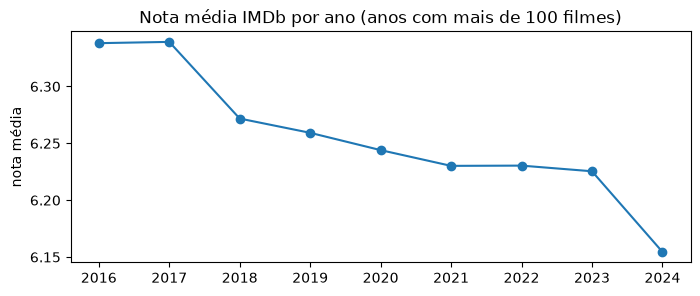

,ano,nota_media,filmes
0,2016,6.34,10381
1,2017,6.34,11189
2,2018,6.27,11327
3,2019,6.26,11637
4,2020,6.24,9534
5,2021,6.23,9578
6,2022,6.23,9887
7,2023,6.23,7809
8,2024,6.15,1621
9,2025,6.58,4


In [12]:
nota_ano = q("""
SELECT m.ano_lancamento AS ano, AVG(f.nota_imdb) AS nota_media, COUNT(*) AS filmes
FROM fact_movies_performance f JOIN dim_movies m ON m.sk_movie_id = f.sk_movie_id
WHERE f.nota_imdb IS NOT NULL GROUP BY ano ORDER BY ano
""")
fig, ax = plt.subplots(figsize=(8, 3))
base = nota_ano[nota_ano["filmes"] > 100]
ax.plot(base["ano"], base["nota_media"], marker="o")
ax.set_title("Nota média IMDb por ano (anos com mais de 100 filmes)")
ax.set_ylabel("nota média")
plt.show()
nota_ano

Os anos de 2025 em diante têm 1 a 4 filmes com nota, então a média deles não é representativa.

## 4. Títulos repetidos e filmes futuros

In [13]:
q("""
SELECT titulo, COUNT(*) AS vezes, COUNT(DISTINCT data_lancamento) AS datas_diferentes
FROM dim_movies GROUP BY titulo HAVING COUNT(*) > 1 ORDER BY vezes DESC LIMIT 6
""")

,titulo,vezes,datas_diferentes
0,Emesis Blue,36,4
1,Die Hart 2: Die Harter,30,4
2,Home,25,25
3,Die Hart: Die Harter,24,5
4,Spider-man: Lotus,22,6
5,Mother,18,18


In [14]:
q("SELECT status_filme, COUNT(*) AS filmes, MIN(ano_lancamento) AS de, MAX(ano_lancamento) AS ate FROM dim_movies GROUP BY 1")

,status_filme,filmes,de,ate
0,Em Produção,598,2023,2024
1,Lançado,94304,2016,2026
2,Planejado,50,2023,2029
3,Pós-Produção,693,2020,2025


**Pegadinha 6:** títulos se repetem (remakes, homônimos e registros duplicados — *Emesis Blue*
aparece 36 vezes). ➡️ Regra: agrupar sempre por `sk_movie_id` e mostrar o ano junto do título.

**Pegadinha 7:** tem filme planejado até 2029. ➡️ Regra: "lançados nos últimos N anos" usa
`status_filme = 'Lançado'` e `data_lancamento <= date('now')`.

## 5. Pessoas (elenco e equipe)

In [15]:
q("""
SELECT p.tipo_pessoa, COUNT(DISTINCT p.sk_person_id) AS pessoas, COUNT(*) AS participacoes
FROM bridge_movie_person b JOIN dim_people p ON p.sk_person_id = b.sk_person_id
GROUP BY p.tipo_pessoa
""")

,tipo_pessoa,pessoas,participacoes
0,Ator,264299,528617
1,Diretor,63148,94212
2,Roteirista,83326,122621


In [16]:
q("""
SELECT COUNT(*) AS nomes_com_mais_de_um_papel FROM (
    SELECT nome_pessoa FROM dim_people GROUP BY nome_pessoa HAVING COUNT(DISTINCT tipo_pessoa) > 1)
""")

,nomes_com_mais_de_um_papel
0,48210


A mesma pessoa tem um `sk_person_id` diferente para cada papel. Na pergunta "dupla ator–diretor",
quem dirige e atua no próprio filme formaria uma "dupla" consigo mesmo.
➡️ Regra: filtrar `tipo_pessoa` e exigir nomes diferentes.

### Desempenho da consulta de duplas

In [17]:
sql_cte = """
WITH atores AS (SELECT b.sk_movie_id, b.sk_person_id FROM bridge_movie_person b
                JOIN dim_people p ON p.sk_person_id = b.sk_person_id WHERE p.tipo_pessoa = 'Ator'),
     diretores AS (SELECT b.sk_movie_id, b.sk_person_id FROM bridge_movie_person b
                JOIN dim_people p ON p.sk_person_id = b.sk_person_id WHERE p.tipo_pessoa = 'Diretor')
SELECT pa.nome_pessoa AS ator, pd.nome_pessoa AS diretor, COUNT(*) AS filmes
FROM atores a JOIN diretores d ON d.sk_movie_id = a.sk_movie_id
JOIN dim_people pa ON pa.sk_person_id = a.sk_person_id
JOIN dim_people pd ON pd.sk_person_id = d.sk_person_id
WHERE pa.nome_pessoa <> pd.nome_pessoa
GROUP BY a.sk_person_id, d.sk_person_id ORDER BY filmes DESC LIMIT 5
"""
inicio = time.time()
duplas = q(sql_cte)
print(f"conexão padrão: {time.time() - inicio:.1f}s")
duplas

conexão padrão: 85.3s


,ator,diretor,filmes
0,Joe Anoa'i,Kevin Dunn,37
1,Colby Lopez,Kevin Dunn,32
2,David Love,Chad Payne,31
3,Anton Pelizzari,Chad Payne,31
4,Cameron Nichols,Chad Payne,31


Muito lento pra um agente que deveria responder "em tempo real". Minha primeira ideia foi que o
problema era a forma da consulta, mas reescrevendo sem as CTEs (JOIN direto) continuou levando mais
de 1 minuto (86 s no meu teste). O gargalo é o **cache do SQLite**, que por padrão tem só 2 MB: o GROUP BY
em chaves de 64 caracteres fica indo ao disco o tempo todo. Testando com a mesma configuração que
o agente usa em `banco.py`:

In [18]:
conn_rapida = sqlite3.connect(URI, uri=True)
conn_rapida.execute("PRAGMA cache_size = -131072")   # ~128 MB
conn_rapida.execute("PRAGMA temp_store = MEMORY")
conn_rapida.execute("PRAGMA mmap_size = 268435456")

inicio = time.time()
pd.read_sql_query(sql_cte, conn_rapida)
print(f"com cache maior: {time.time() - inicio:.1f}s")
conn_rapida.close()

com cache maior: 17.7s


Caiu para ~17 s só mudando a configuração da conexão. Num teste separado, com a conexão ajustada,
a versão sem CTE deu 17,8 s e a com CTE 16,6 s, ou seja, quem resolveu foi o cache e não a forma da
consulta. Deixei o exemplo com CTE no prompt só porque fica mais claro de ler.

## 6. Sinopses (para a busca semântica)

In [19]:
q("""
SELECT SUM(sinopse = 'Sem descrição') AS sem_descricao,
       SUM(sinopse <> 'Sem descrição') AS com_sinopse,
       ROUND(AVG(CASE WHEN sinopse <> 'Sem descrição' THEN LENGTH(sinopse) END)) AS tamanho_medio
FROM dim_movies
""")

,sem_descricao,com_sinopse,tamanho_medio
0,13730,81915,263.00


In [20]:
q("SELECT titulo, SUBSTR(sinopse, 1, 120) AS sinopse FROM dim_movies WHERE sinopse <> 'Sem descrição' LIMIT 3")

,titulo,sinopse
0,Rings,"""Julia becomes worried about her boyfriend Hol..."
1,Mixtape,"On the eve of Y2K, orphaned 12-year-old Beverl..."
2,Grizzly Ii: Revenge,"""All hell breaks loose when a giant grizzly, r..."


As sinopses estão em **inglês** e ~14 mil filmes têm o placeholder "Sem descrição" (ficam fora do
índice). Como as perguntas vão ser em português, escolhi um modelo de embedding **multilíngue**.

## 7. Avaliações dos usuários

In [21]:
q("""
SELECT COUNT(*) AS filmes_avaliados,
       SUM(ABS(d.nota_media_usuarios - a.media) > 0.01) AS media_diferente,
       SUM(d.qtd_avaliacoes_usuarios <> a.n) AS qtd_diferente,
       MAX(d.qtd_avaliacoes_usuarios) AS max_avaliacoes
FROM dim_reviews d
JOIN (SELECT sk_movie_id, AVG(rating) AS media, COUNT(*) AS n FROM movie_reviews GROUP BY 1) a
  ON a.sk_movie_id = d.sk_movie_id
""")

,filmes_avaliados,media_diferente,qtd_diferente,max_avaliacoes
0,40267,0,0,13


`dim_reviews` é exatamente o resumo de `movie_reviews` (nenhuma divergência). O máximo é 13
avaliações por filme e há muitos empates — por isso, na avaliação automática, essas perguntas
comparam os **valores** e não a ordem dos títulos.

## Resumo: achados → regras do prompt

| # | Achado | Regra no prompt |
|---|---|---|
| 1 | lucro nunca é nulo (nulo tratado como 0) | lucro só com receita e orçamento informados |
| 2 | orçamento em R$ com câmbio truncado (3,0 / 4,0) | margens em US$ |
| 3 | margem média simples dominada por receitas de US$ 1 | margem média = Σlucro/Σreceita |
| 4 | nota TMDB = 0 quando não há voto | `qtd_tmdb > 0` |
| 5 | popularidade = ano em 4 filmes | avisar o usuário |
| 6 | títulos repetidos | agrupar por `sk_movie_id` |
| 7 | filmes futuros (até 2029) | "lançados" = status Lançado e data ≤ hoje |
| 8 | pessoa tem um registro por papel | filtrar `tipo_pessoa`, nomes diferentes nas duplas |
| 9 | consulta de duplas levava de 1 a 2,5 min | cache maior na conexão (PRAGMA) em `banco.py` |

In [22]:
conn.close()